# TIMMD — 04: Escenarios Contrafácticos

Este notebook entrena un modelo de xG utilizando partidos de referencia y lo utiliza para evaluar escenarios alternativos de la final del Mundial. La estructura está organizada para facilitar la incorporación de nuevos casos sin duplicar código.

## 1. Configuración del entorno

Montaje de Drive, rutas y librerías generales.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── RUTA DE DATOS ─────────────────────────────────────────
# Si sos colaborador: abrí este link y hacé click en
# "Agregar acceso directo a Mi unidad" guardándolo como "TIMMD":
# https://drive.google.com/drive/folders/1JCn2VRcg4vnjB5G0cq40gpGMgddG1PQR

DATA_DIR = "/content/drive/MyDrive/TIMMD/data"
MATCH_ID = 3869685 # ESTE NO SE TOCA

print(f"✓ {len(os.listdir(DATA_DIR))} archivos en data/")



Mounted at /content/drive
✓ 63 archivos en data/


In [3]:
import pandas as pd
import numpy as np
import glob

MATCH_IDS_TRAIN = [
    3857279, 3857266, 3857275, 3869152, 3869354, 3869552, 3869685,
    3857300, 3857289, 3857264, 3869151, 3869321, 3869519
]

todos = []
for mid in MATCH_IDS_TRAIN:
    path = f"{DATA_DIR}/eventos_{mid}.parquet"
    df = pd.read_parquet(path)
    df['match_id'] = mid
    todos.append(df)

todos_eventos = pd.concat(todos, ignore_index=True)

eventos = todos_eventos[todos_eventos['match_id'] == MATCH_ID].copy()
equipos = eventos['team'].dropna().unique().tolist()
equipo_local = equipos[0]
equipo_visit = equipos[1]

print(f"Partidos cargados: {len(MATCH_IDS_TRAIN)}")
print(f"Total eventos: {todos_eventos.shape[0]}")
print(f"\nAnalizando: {equipo_local} vs {equipo_visit}")

Partidos cargados: 13
Total eventos: 49615

Analizando: Argentina vs France


## 2. Entrenamiento del modelo xG

Construcción del dataset de tiros y entrenamiento del modelo utilizado en las simulaciones.

In [4]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option('future.no_silent_downcasting', True)

tiros_todos = todos_eventos[todos_eventos['type'] == 'Shot'].copy()

tiros_todos['x'] = tiros_todos['location'].apply(lambda l: l[0] if hasattr(l, '__len__') else None)
tiros_todos['y'] = tiros_todos['location'].apply(lambda l: l[1] if hasattr(l, '__len__') else None)

tiros_todos['distancia'] = np.sqrt((tiros_todos['x'] - 120)**2 + (tiros_todos['y'] - 40)**2)
tiros_todos['angulo']    = np.abs(np.arctan2(
    np.abs(tiros_todos['y'] - 40), (120 - tiros_todos['x']))) * 180 / np.pi

tiros_todos['es_cabeza']        = (tiros_todos['shot_body_part'] == 'Head').astype(int)
tiros_todos['bajo_presion']     = tiros_todos['under_pressure'].fillna(False).astype(int)
tiros_todos['es_volea']         = (tiros_todos['shot_technique'] == 'Volley').astype(int)
tiros_todos['es_media_vuelta']  = (tiros_todos['shot_technique'] == 'Half Volley').astype(int)
tiros_todos['es_contragolpe']   = (tiros_todos['play_pattern'] == 'From Counter Press').astype(int)
tiros_todos['es_pelota_parada'] = (tiros_todos['play_pattern'].isin(
    ['From Corner', 'From Free Kick', 'From Throw In'])).astype(int)
tiros_todos['dentro_area']      = (
    (tiros_todos['x'] > 102) & (tiros_todos['y'].between(18, 62))).astype(int)
tiros_todos['centralidad']      = 1 - (np.abs(tiros_todos['y'] - 40) / 40).clip(0, 1)
tiros_todos['gol']              = (tiros_todos['shot_outcome'] == 'Goal').astype(int)
tiros_todos['es_penal']         = (tiros_todos['shot_type'] == 'Penalty')

tiros_todos = tiros_todos[tiros_todos['period'] < 5].copy()

FEATURES = ['distancia', 'angulo', 'es_cabeza', 'bajo_presion',
            'es_volea', 'es_media_vuelta', 'es_contragolpe',
            'es_pelota_parada', 'dentro_area', 'centralidad']

tiros_todos = tiros_todos.dropna(subset=FEATURES)
tiros_train = tiros_todos[~tiros_todos['es_penal']].copy()

X = tiros_train[FEATURES]
y = tiros_train['gol']

modelo = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(random_state=42))
])
modelo.fit(X, y)

tiros_todos.loc[~tiros_todos['es_penal'], 'prob_gol'] = \
    modelo.predict_proba(tiros_todos.loc[~tiros_todos['es_penal'], FEATURES])[:, 1]
tiros_todos.loc[tiros_todos['es_penal'], 'prob_gol'] = 0.78

tiros = tiros_todos[tiros_todos['match_id'] == MATCH_ID].copy()

print(f"Tiros para entrenar (sin penales): {len(tiros_train)}")
print(f"Goles: {tiros_train['gol'].sum()} ({tiros_train['gol'].mean()*100:.1f}%)")
print(f"\nTiros en la final: {len(tiros)}")
print(f"\nDistribución prob_gol en la final:")
print(tiros['prob_gol'].describe().round(3))

Tiros para entrenar (sin penales): 288
Goles: 32 (11.1%)

Tiros en la final: 30

Distribución prob_gol en la final:
count    30.000
mean      0.180
std       0.228
min       0.007
25%       0.033
50%       0.090
75%       0.256
max       0.780
Name: prob_gol, dtype: float64


## 3. Funciones de simulación

Definición de la lógica utilizada para ejecutar escenarios contrafácticos.

In [5]:
N_SIMULACIONES = 100_000
np.random.seed(42)

def simular_resultado(goles_arg, goles_fra, xg_arg, xg_fra, n=N_SIMULACIONES):
    goles_extra_arg = np.random.poisson(xg_arg, n)
    goles_extra_fra = np.random.poisson(xg_fra, n)
    final_arg = goles_arg + goles_extra_arg
    final_fra = goles_fra + goles_extra_fra
    return (np.sum(final_arg > final_fra) / n,
            np.sum(final_arg == final_fra) / n,
            np.sum(final_arg < final_fra) / n)

MINUTO_CORTE  = 35
PERIODO_CORTE = 1

tiros_resto = tiros[
    (~tiros['es_penal']) & (
        tiros['period'] == 2
    )
].copy()

xg_arg_b = tiros_resto[tiros_resto['team'] == equipo_local]['prob_gol'].sum()
xg_fra_b = tiros_resto[tiros_resto['team'] == equipo_visit]['prob_gol'].sum()

print(f"xG restante ARG (solo 2do tiempo): {xg_arg_b:.3f}")
print(f"xG restante FRA (solo 2do tiempo): {xg_fra_b:.3f}")

p_arg_real_b, p_emp_real_b, p_fra_real_b = simular_resultado(
    goles_arg=2, goles_fra=0, xg_arg=xg_arg_b, xg_fra=xg_fra_b)

p_arg_alt_b, p_emp_alt_b, p_fra_alt_b = simular_resultado(
    goles_arg=1, goles_fra=0, xg_arg=xg_arg_b, xg_fra=xg_fra_b)

print("=" * 50)
print(f"ESCENARIO — Di María convierte (2-0) vs falla (1-0)")
print(f"  xG restante ARG : {xg_arg_b:.3f}")
print(f"  xG restante FRA : {xg_fra_b:.3f}")
print("=" * 50)
print(f"REAL  — Di María convierte (2-0)")
print(f"  Argentina gana : {p_arg_real_b*100:.1f}%")
print(f"  Empate         : {p_emp_real_b*100:.1f}%")
print(f"  Francia gana   : {p_fra_real_b*100:.1f}%")
print("=" * 50)
print(f"ALT   — Di María falla (1-0)")
print(f"  Argentina gana : {p_arg_alt_b*100:.1f}%")
print(f"  Empate         : {p_emp_alt_b*100:.1f}%")
print(f"  Francia gana   : {p_fra_alt_b*100:.1f}%")
print("=" * 50)

xG restante ARG (solo 2do tiempo): 0.554
xG restante FRA (solo 2do tiempo): 0.433
ESCENARIO — Di María convierte (2-0) vs falla (1-0)
  xG restante ARG : 0.554
  xG restante FRA : 0.433
REAL  — Di María convierte (2-0)
  Argentina gana : 95.6%
  Empate         : 3.7%
  Francia gana   : 0.6%
ALT   — Di María falla (1-0)
  Argentina gana : 77.4%
  Empate         : 18.2%
  Francia gana   : 4.4%


## 4. Escenario: Di María

Comparación entre el resultado real y un escenario alternativo.

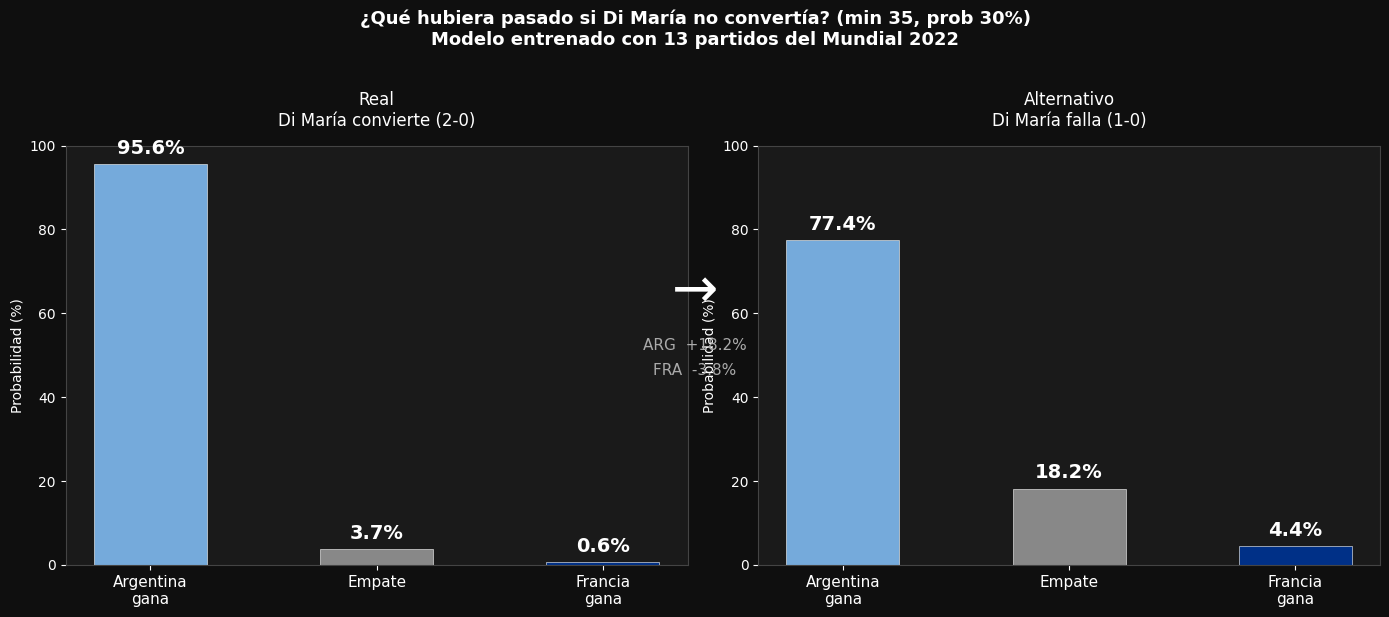

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("#0f0f0f")

color_arg = "#75AADB"
color_fra = "#003087"
color_emp = "#888888"

escenarios = {
    "Real\nDi María convierte (2-0)": (p_arg_real_b, p_emp_real_b, p_fra_real_b),
    "Alternativo\nDi María falla (1-0)":  (p_arg_alt_b, p_emp_alt_b, p_fra_alt_b),
}

for ax, (titulo, (p_arg, p_emp, p_fra)) in zip(axes, escenarios.items()):
    ax.set_facecolor("#1a1a1a")

    categorias = ["Argentina\ngana", "Empate", "Francia\ngana"]
    valores    = [p_arg * 100, p_emp * 100, p_fra * 100]
    colores    = [color_arg, color_emp, color_fra]

    bars = ax.bar(categorias, valores, color=colores, width=0.5,
                  edgecolor="white", linewidth=0.4)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f"{val:.1f}%",
                ha="center", va="bottom",
                fontsize=14, fontweight="bold", color="white")

    ax.set_ylim(0, 100)
    ax.set_title(titulo, fontsize=12, color="white", pad=14)
    ax.tick_params(colors="white")
    ax.set_ylabel("Probabilidad (%)", color="white")
    ax.spines[:].set_color("#444444")
    ax.yaxis.label.set_color("white")
    for label in ax.get_xticklabels():
        label.set_color("white")
        label.set_fontsize(11)

delta_arg = (p_arg_real_b - p_arg_alt_b) * 100
delta_fra = (p_fra_real_b - p_fra_alt_b) * 100

fig.text(0.5, 0.55, "→", ha="center", va="center",
         fontsize=40, color="white", transform=fig.transFigure)

fig.text(0.5, 0.44,
         f"ARG  {delta_arg:+.1f}%\nFRA  {delta_fra:+.1f}%",
         ha="center", va="center",
         fontsize=11, color="#aaaaaa",
         transform=fig.transFigure,
         linespacing=1.8)

fig.suptitle(
    f"¿Qué hubiera pasado si Di María no convertía? (min 35, prob {0.30:.0%})\n"
    f"Modelo entrenado con {len(MATCH_IDS_TRAIN)} partidos del Mundial 2022",
    fontsize=13, fontweight="bold", color="white", y=1.02
)

plt.tight_layout()
plt.show()

## 5. Escenario: Mbappé

Aplicación del mismo modelo a un segundo caso de estudio.

In [7]:
tiros_resto_c = tiros[
    (~tiros['es_penal']) & (
        tiros['period'] == 4
    ) & (tiros['minute'] > 117)
].copy()

xg_arg_c = tiros_resto_c[tiros_resto_c['team'] == equipo_local]['prob_gol'].sum()
xg_fra_c = tiros_resto_c[tiros_resto_c['team'] == equipo_visit]['prob_gol'].sum()

p_arg_real_c, p_emp_real_c, p_fra_real_c = simular_resultado(
    goles_arg=3, goles_fra=3, xg_arg=xg_arg_c, xg_fra=xg_fra_c)

p_arg_alt_c, p_emp_alt_c, p_fra_alt_c = simular_resultado(
    goles_arg=3, goles_fra=2, xg_arg=xg_arg_c, xg_fra=xg_fra_c)

print(f"xG restante ARG (period 4, min >117): {xg_arg_c:.3f}")
print(f"xG restante FRA (period 4, min >117): {xg_fra_c:.3f}")
print("=" * 50)
print(f"REAL  — Mbappé convierte (3-3)")
print(f"  Argentina gana : {p_arg_real_c*100:.1f}%")
print(f"  Empate         : {p_emp_real_c*100:.1f}%")
print(f"  Francia gana   : {p_fra_real_c*100:.1f}%")
print("=" * 50)
print(f"ALT   — Mbappé falla (3-2)")
print(f"  Argentina gana : {p_arg_alt_c*100:.1f}%")
print(f"  Empate         : {p_emp_alt_c*100:.1f}%")
print(f"  Francia gana   : {p_fra_alt_c*100:.1f}%")
print("=" * 50)

xG restante ARG (period 4, min >117): 0.267
xG restante FRA (period 4, min >117): 0.107
REAL  — Mbappé convierte (3-3)
  Argentina gana : 21.2%
  Empate         : 70.9%
  Francia gana   : 7.9%
ALT   — Mbappé falla (3-2)
  Argentina gana : 92.0%
  Empate         : 7.6%
  Francia gana   : 0.4%


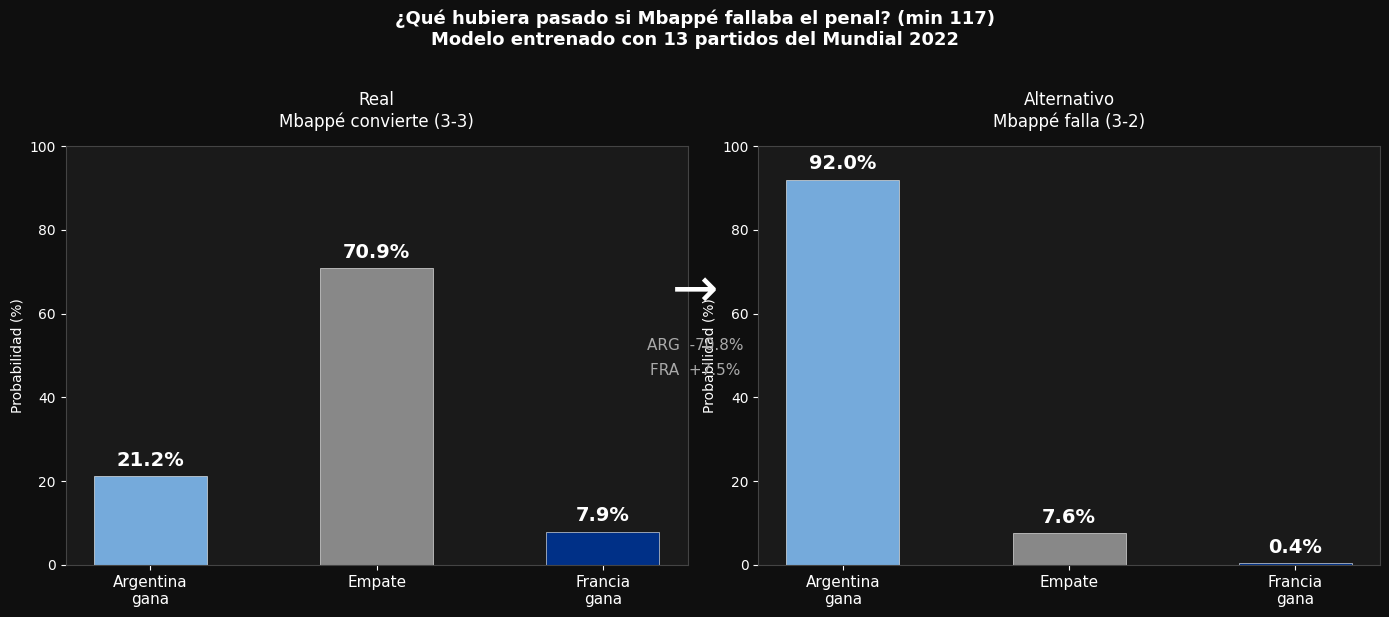

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("#0f0f0f")

escenarios = {
    "Real\nMbappé convierte (3-3)": (p_arg_real_c, p_emp_real_c, p_fra_real_c),
    "Alternativo\nMbappé falla (3-2)":  (p_arg_alt_c, p_emp_alt_c, p_fra_alt_c),
}

for ax, (titulo, (p_arg, p_emp, p_fra)) in zip(axes, escenarios.items()):
    ax.set_facecolor("#1a1a1a")

    categorias = ["Argentina\ngana", "Empate", "Francia\ngana"]
    valores    = [p_arg * 100, p_emp * 100, p_fra * 100]
    colores    = [color_arg, color_emp, color_fra]

    bars = ax.bar(categorias, valores, color=colores, width=0.5,
                  edgecolor="white", linewidth=0.4)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f"{val:.1f}%",
                ha="center", va="bottom",
                fontsize=14, fontweight="bold", color="white")

    ax.set_ylim(0, 100)
    ax.set_title(titulo, fontsize=12, color="white", pad=14)
    ax.tick_params(colors="white")
    ax.set_ylabel("Probabilidad (%)", color="white")
    ax.spines[:].set_color("#444444")
    ax.yaxis.label.set_color("white")
    for label in ax.get_xticklabels():
        label.set_color("white")
        label.set_fontsize(11)

delta_arg = (p_arg_real_c - p_arg_alt_c) * 100
delta_fra = (p_fra_real_c - p_fra_alt_c) * 100

fig.text(0.5, 0.55, "→", ha="center", va="center",
         fontsize=40, color="white", transform=fig.transFigure)

fig.text(0.5, 0.44,
         f"ARG  {delta_arg:+.1f}%\nFRA  {delta_fra:+.1f}%",
         ha="center", va="center",
         fontsize=11, color="#aaaaaa",
         transform=fig.transFigure,
         linespacing=1.8)

fig.suptitle(
    f"¿Qué hubiera pasado si Mbappé fallaba el penal? (min 117)\n"
    f"Modelo entrenado con {len(MATCH_IDS_TRAIN)} partidos del Mundial 2022",
    fontsize=13, fontweight="bold", color="white", y=1.02
)

plt.tight_layout()
plt.show()